In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("customer_shopping_data.csv")
df.head()

,invoice_no,customer_id,gender,age,category,quantity,price,payment_method,invoice_date,shopping_mall
0,I138884,C241288,Female,28,Clothing,5,1500.40,Credit Card,5/8/2022,Kanyon
1,I317333,C111565,Male,21,Shoes,3,1800.51,Debit Card,12/12/2021,Forum Istanbul
2,I127801,C266599,Male,20,Clothing,1,300.08,Cash,9/11/2021,Metrocity
3,I173702,C988172,Female,66,Shoes,5,3000.85,Credit Card,16/05/2021,Metropol AVM
4,I337046,C189076,Female,53,Books,4,60.60,Cash,24/10/2021,Kanyon


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99457 entries, 0 to 99456
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   invoice_no      99457 non-null  object 
 1   customer_id     99457 non-null  object 
 2   gender          99457 non-null  object 
 3   age             99457 non-null  int64  
 4   category        99457 non-null  object 
 5   quantity        99457 non-null  int64  
 6   price           99457 non-null  float64
 7   payment_method  99457 non-null  object 
 8   invoice_date    99457 non-null  object 
 9   shopping_mall   99457 non-null  object 
dtypes: float64(1), int64(2), object(7)
memory usage: 7.6+ MB


In [5]:
df.shape

(99457, 10)

In [6]:
df.isnull().sum()

invoice_no        0
customer_id       0
gender            0
age               0
category          0
quantity          0
price             0
payment_method    0
invoice_date      0
shopping_mall     0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.describe().round(2)

,age,quantity,price
count,99457.00,99457.00,99457.00
mean,43.43,3.00,689.26
std,14.99,1.41,941.18
min,18.00,1.00,5.23
25%,30.00,2.00,45.45
50%,43.00,3.00,203.30
75%,56.00,4.00,1200.32
max,69.00,5.00,5250.00


In [9]:
df.describe(include = "object")

,invoice_no,customer_id,gender,category,payment_method,invoice_date,shopping_mall
count,99457,99457,99457,99457,99457,99457,99457
unique,99457,99457,2,8,3,797,10
top,I232867,C273973,Female,Clothing,Cash,24/11/2021,Mall of Istanbul
freq,1,1,59482,34487,44447,159,19943


## Initial Observations

The dataset contains 99,457 shopping transactions. The average
customer age is 43.43 years, with customers ranging from 18 to 69
years old.

The average quantity purchased per transaction is 3 items. The
price variable has a mean of USD 689.26 and a median of USD 203.30,
indicating substantial variation in purchase prices and the presence
of high-value transactions.

Clothing isthe most frequently purchased category, and Cash is the most common
payment method.

In [10]:
df['invoice_date'] = pd.to_datetime(df['invoice_date'], dayfirst = True)

In [11]:
df["invoice_date"].dtype

dtype('<M8[ns]')

In [12]:
df["year"] = df["invoice_date"].dt.year
df["month"] = df["invoice_date"].dt.month

In [13]:
df["month_name"] = df["invoice_date"].dt.month_name()

In [14]:
df['revenue'] = df['quantity']*df['price']

In [15]:
df[["quantity", "price", "revenue"]].head()

,quantity,price,revenue
0,5,1500.40,7502.00
1,3,1800.51,5401.53
2,1,300.08,300.08
3,5,3000.85,15004.25
4,4,60.60,242.40


In [16]:
df["revenue"].sum()

np.float64(251505794.25000003)

In [17]:
df["revenue"].mean()

np.float64(2528.78926822647)

In [18]:
category_revenue = (df.groupby("category")['revenue'].sum().sort_values(ascending = False))

category_revenue.apply(lambda x: f"${x:,.2f}")

category
Clothing           $113,996,791.04
Shoes               $66,553,451.47
Technology          $57,862,350.00
Cosmetics            $6,792,862.90
Toys                 $3,980,426.24
Food & Beverage        $849,535.05
Books                  $834,552.90
Souvenir               $635,824.65
Name: revenue, dtype: object

In [19]:
avg_purchase_category = (df.groupby("category")['revenue'].mean().sort_values(ascending = False))
avg_purchase_category

category
Technology         11581.735388
Shoes               6632.793649
Clothing            3305.500364
Cosmetics            449.947864
Toys                 394.609521
Books                167.547260
Souvenir             127.190368
Food & Beverage       57.494251
Name: revenue, dtype: float64

In [20]:
mall_revenue = (df.groupby('shopping_mall')['revenue'].sum().sort_values(ascending = False))
mall_revenue

shopping_mall
Mall of Istanbul     50872481.68
Kanyon               50554231.10
Metrocity            37302787.33
Metropol AVM         25379913.19
Istinye Park         24618827.68
Zorlu Center         12901053.82
Cevahir AVM          12645138.20
Viaport Outlet       12521339.72
Emaar Square Mall    12406100.29
Forum Istanbul       12303921.24
Name: revenue, dtype: float64

In [21]:
mall_avg_purchase = (df.groupby("shopping_mall")["revenue"].mean().sort_values(ascending=False))
mall_avg_purchase

shopping_mall
Emaar Square Mall    2578.694718
Mall of Istanbul     2550.894132
Kanyon               2550.281547
Viaport Outlet       2548.095181
Zorlu Center         2542.079570
Cevahir AVM          2533.588099
Istinye Park         2517.005181
Metropol AVM         2497.777108
Forum Istanbul       2487.148017
Metrocity            2485.030133
Name: revenue, dtype: float64

In [22]:
payment_revenue = (df.groupby('payment_method')['revenue'].sum().sort_values(ascending = False))
payment_revenue

payment_method
Cash           1.128322e+08
Credit Card    8.807712e+07
Debit Card     5.059643e+07
Name: revenue, dtype: float64

In [23]:
payment_transactions = (df.groupby("payment_method")["invoice_no"].nunique().sort_values(ascending=False))
payment_transactions

payment_method
Cash           44447
Credit Card    34931
Debit Card     20079
Name: invoice_no, dtype: int64

In [24]:
payment_avg_purchase = (df.groupby("payment_method")["revenue"].mean().sort_values(ascending=False))
payment_avg_purchase

payment_method
Cash           2538.579500
Credit Card    2521.460129
Debit Card     2519.867895
Name: revenue, dtype: float64

Cash generates the highest revenue primarily because it is used in more transactions, rather than because cash transactions have substantially higher average values.

In [25]:
payment_transaction_share = (payment_transactions / payment_transactions.sum() * 100).round(2)
payment_transaction_share

payment_method
Cash           44.69
Credit Card    35.12
Debit Card     20.19
Name: invoice_no, dtype: float64

In [26]:
gender_revenue = (df.groupby("gender")["revenue"].sum().sort_values(ascending=False))
gender_revenue

gender
Female    1.502071e+08
Male      1.012987e+08
Name: revenue, dtype: float64

In [27]:
gender_transactions = (df.groupby("gender")["invoice_no"].nunique().sort_values(ascending=False))
gender_transactions

gender
Female    59482
Male      39975
Name: invoice_no, dtype: int64

In [28]:
gender_avg_purchase = (df.groupby("gender")["revenue"].mean().sort_values(ascending=False))
gender_avg_purchase

gender
Male      2534.050237
Female    2525.253623
Name: revenue, dtype: float64

In [29]:
gender_transaction_share = (gender_transactions / gender_transactions.sum() * 100).round(2)
gender_transaction_share

gender
Female    59.81
Male      40.19
Name: invoice_no, dtype: float64

Female customers generate more total revenue because they account for a larger share of transactions, while average transaction values are very similar between male and female customers.

In [30]:
mall_category_pivot = pd.pivot_table(df, values = 'revenue', index = 'shopping_mall', columns = 'category', aggfunc='sum', fill_value = 0)
mall_category_pivot

category,Books,Clothing,Cosmetics,Food & Beverage,Shoes,Souvenir,Technology,Toys
shopping_mall,,,,,,,,
Cevahir AVM,44541.00,5706321.28,321214.00,44010.45,3243918.85,29723.82,3051300.0,204108.80
Emaar Square Mall,41995.80,5590490.40,338941.76,40610.95,3089675.16,30943.74,3094350.0,179092.48
Forum Istanbul,42056.40,5792444.24,353172.76,39162.24,3327942.65,32879.19,2516850.0,199413.76
Istinye Park,76083.30,11253900.24,655357.88,85918.44,6641481.22,68925.48,5436900.0,400261.12
Kanyon,163029.15,22609527.60,1369550.78,166497.05,13383190.83,127399.53,11944800.0,790236.16
Mall of Istanbul,172240.35,22947417.68,1367517.78,171177.90,13467814.80,127540.29,11828250.0,790522.88
Metrocity,125911.65,17226692.56,991860.04,129902.74,9519296.37,94227.09,8608950.0,605946.88
Metropol AVM,83718.90,11568084.00,680770.38,88638.04,7149825.21,67869.78,5327700.0,413306.88
Viaport Outlet,39632.40,5604594.16,347439.70,41662.18,3194704.91,27319.17,3066000.0,199987.20


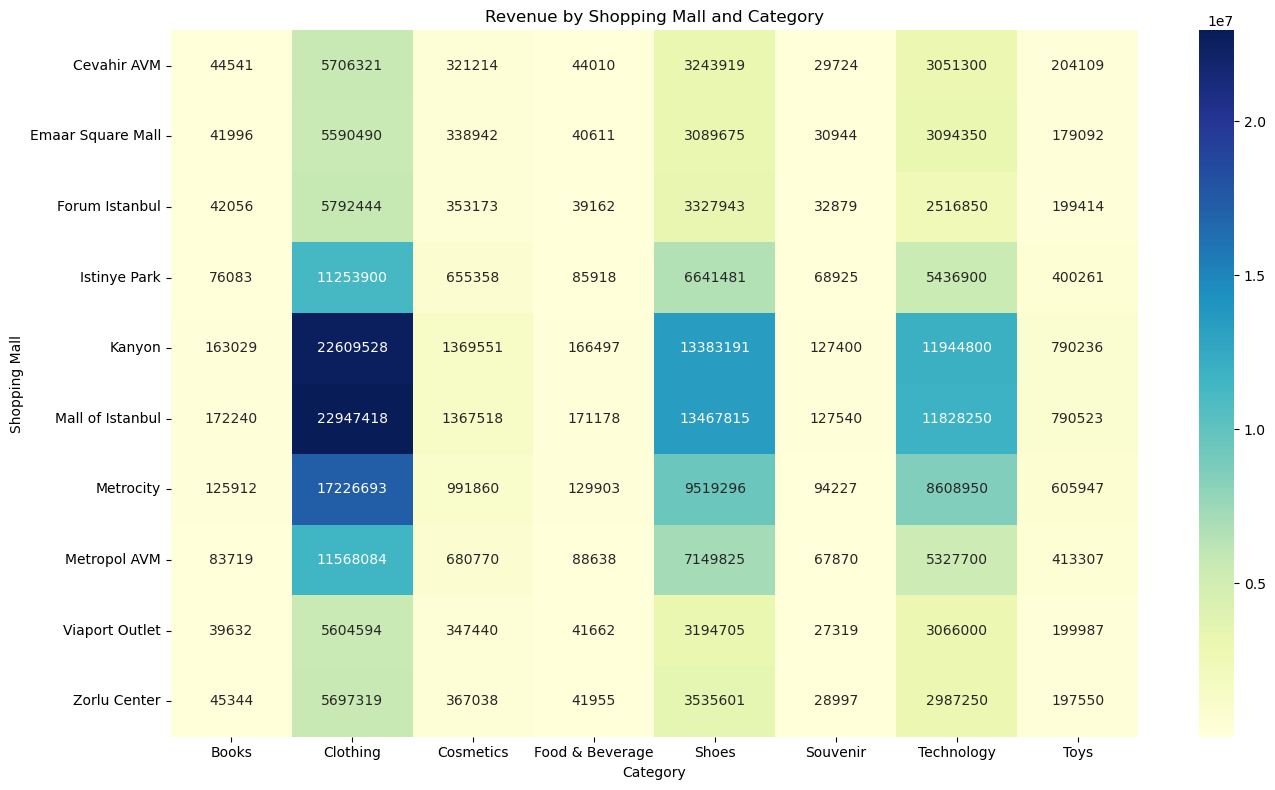

In [39]:
plt.figure(figsize=(14, 8))
sns.heatmap(mall_category_pivot, annot=True,fmt=".0f", cmap="YlGnBu")
plt.title("Revenue by Shopping Mall and Category")
plt.xlabel("Category")
plt.ylabel("Shopping Mall")

plt.savefig( "revenue_by_mall_category.png",dpi=300,bbox_inches="tight")
plt.tight_layout()
plt.show()

### Interpretation

The heatmap shows revenue distribution across shopping malls and
product categories. Clothing generates the highest revenue across
all shopping malls, followed by Shoes and Technology in most cases.

Mall of Istanbul and Kanyon show particularly high revenue across
the major categories, especially Clothing, Shoes and Technology.

In contrast, Books, Food & Beverage and Souvenir contribute
substantially lower revenue across the malls.

The heatmap demonstrates that revenue patterns are relatively
consistent across shopping malls, while the magnitude of revenue
varies considerably between malls.

In [32]:
yearly_category = (df.groupby(["year", "category"])["revenue"].sum().reset_index())
yearly_category.head()

,year,category,revenue
0,2021,Books,369008.55
1,2021,Clothing,52604924.24
2,2021,Cosmetics,3033723.92
3,2021,Food & Beverage,390848.36
4,2021,Shoes,30125533.15


In [33]:
yearly_category_pivot = yearly_category.pivot_table(index="year",columns="category",values="revenue")
yearly_category_pivot

category,Books,Clothing,Cosmetics,Food & Beverage,Shoes,Souvenir,Technology,Toys
year,,,,,,,,
2021,369008.55,52604924.24,3033723.92,390848.36,30125533.15,288288.21,25951800.0,1796444.16
2022,391945.65,51753897.36,3150499.44,386852.64,30944765.20,295865.79,26651100.0,1861888.00
2023,73598.70,9637969.44,608639.54,71834.05,5483153.12,51670.65,5259450.0,322094.08


Revenue remained relatively stable between 2021 and 2022, with several categories showing moderate growth while Clothing and Food & Beverage experienced slight declines.

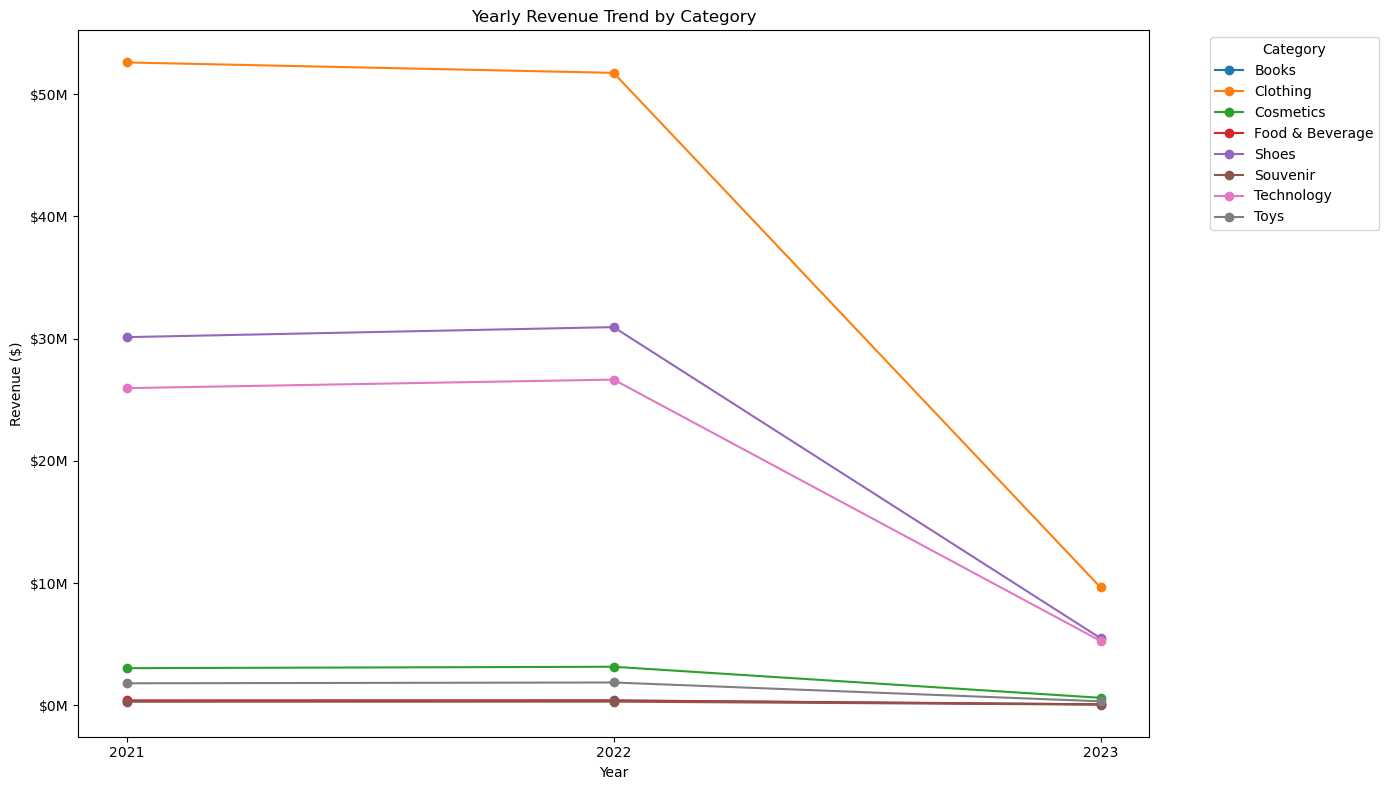

In [40]:
import matplotlib.ticker as mtick

plt.figure(figsize=(14, 8))

for category in yearly_category_pivot.columns:
    plt.plot(yearly_category_pivot.index,yearly_category_pivot[category], marker="o",label=category)

plt.title("Yearly Revenue Trend by Category")
plt.xlabel("Year")
plt.ylabel("Revenue ($)")

# Show only the actual years
plt.xticks([2021, 2022, 2023])

# Format Y-axis in millions
plt.gca().yaxis.set_major_formatter( mtick.FuncFormatter(lambda x, pos: f"${x/1e6:.0f}M"))

plt.legend( title="Category", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.savefig("yearly_revenue_trend.png",dpi=300,bbox_inches="tight")

plt.tight_layout()
plt.show()

In [35]:
gender_category = (df.groupby(["category", "gender"])["revenue"].sum().reset_index())
gender_category

,category,gender,revenue
0,Books,Female,489314.70
1,Books,Male,345238.20
2,Clothing,Female,68251695.60
3,Clothing,Male,45745095.44
4,Cosmetics,Female,4066772.54
5,Cosmetics,Male,2726090.36
6,Food & Beverage,Female,505322.60
7,Food & Beverage,Male,344212.45
8,Shoes,Female,39425167.30
9,Shoes,Male,27128284.17


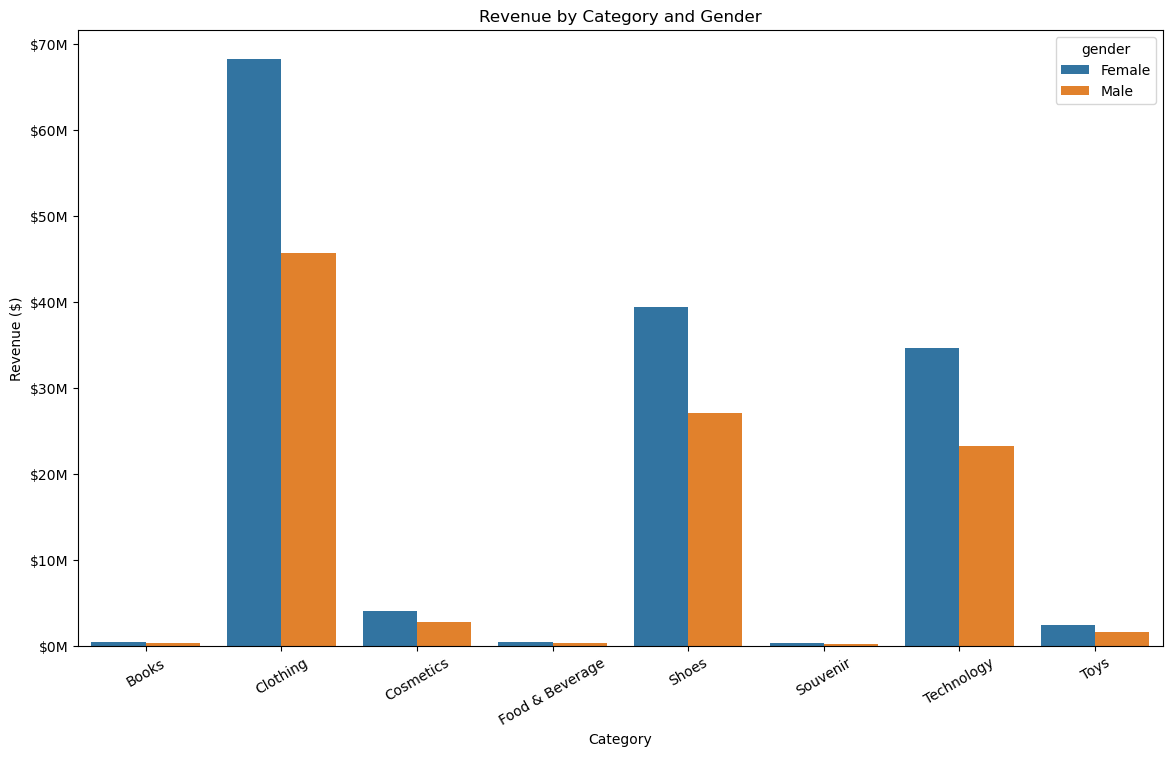

In [41]:
plt.figure(figsize=(14, 8))

sns.barplot( data=gender_category,x="category", y="revenue", hue="gender")

plt.title("Revenue by Category and Gender")
plt.xlabel("Category")
plt.ylabel("Revenue ($)")

plt.xticks(rotation=30)

# Format Y-axis in millions
plt.gca().yaxis.set_major_formatter( mtick.FuncFormatter(lambda x, pos: f"${x/1e6:.0f}M"))
plt.savefig("revenue_by_gender_category.png",dpi=300, bbox_inches="tight")

plt.show()

### Interpretation

Female customers generated higher total revenue than male customers
across all product categories. Clothing generated the highest revenue
for both genders, followed by Shoes and Technology.

The higher total revenue generated by female customers is consistent
with their larger share of transactions in the dataset (59.81% compared
with 40.19% for male customers). 

### Bonus 1

In [67]:
df["year_month"] = df["invoice_date"].dt.to_period("M")

In [68]:
monthly_mall_revenue = (df.groupby(["year_month", "shopping_mall"])["revenue"].sum().reset_index())

In [69]:
monthly_mall_revenue.head()

,year_month,shopping_mall,revenue
0,2021-01,Cevahir AVM,483830.06
1,2021-01,Emaar Square Mall,448750.27
2,2021-01,Forum Istanbul,488872.77
3,2021-01,Istinye Park,971940.08
4,2021-01,Kanyon,2090260.11


In [70]:
monthly_mall_revenue = monthly_mall_revenue.sort_values(["shopping_mall", "year_month"])

In [72]:
monthly_mall_revenue["previous_revenue"] = (monthly_mall_revenue.groupby("shopping_mall")["revenue"].shift(1))


In [73]:
monthly_mall_revenue["mom_growth"] = ((monthly_mall_revenue["revenue"] - monthly_mall_revenue["previous_revenue"])/ monthly_mall_revenue["previous_revenue"] * 100)

In [75]:
monthly_mall_revenue["mom_growth"] = (monthly_mall_revenue["mom_growth"].round(2))

In [76]:
monthly_mall_revenue[monthly_mall_revenue["shopping_mall"] == "Kanyon"].head(10)

,year_month,shopping_mall,revenue,previous_revenue,mom_growth
4,2021-01,Kanyon,2090260.11,NaN,NaN
14,2021-02,Kanyon,1836484.59,2090260.11,-12.14
24,2021-03,Kanyon,2056647.03,1836484.59,11.99
34,2021-04,Kanyon,1852061.65,2056647.03,-9.95
44,2021-05,Kanyon,1956077.82,1852061.65,5.62
54,2021-06,Kanyon,1823885.30,1956077.82,-6.76
64,2021-07,Kanyon,1985569.32,1823885.30,8.86
74,2021-08,Kanyon,2006239.93,1985569.32,1.04
84,2021-09,Kanyon,1898129.05,2006239.93,-5.39
94,2021-10,Kanyon,1999620.01,1898129.05,5.35


In [77]:
monthly_mall_revenue.nlargest(10, "mom_growth")

,year_month,shopping_mall,revenue,previous_revenue,mom_growth
141,2022-03,Emaar Square Mall,620591.58,238914.37,159.75
147,2022-03,Metropol AVM,1158727.34,704531.71,64.47
259,2023-02,Zorlu Center,695376.79,433926.71,60.25
231,2022-12,Emaar Square Mall,490293.31,307617.82,59.38
20,2021-03,Cevahir AVM,512891.12,329264.45,55.77
92,2021-10,Forum Istanbul,573669.52,370238.53,54.95
32,2021-04,Forum Istanbul,626569.32,414271.29,51.25
98,2021-10,Viaport Outlet,559256.29,388258.32,44.04
63,2021-07,Istinye Park,1234963.82,857702.38,43.99
212,2022-10,Forum Istanbul,594366.72,418187.05,42.13


In [78]:
monthly_mall_revenue.nsmallest(10, "mom_growth")

,year_month,shopping_mall,revenue,previous_revenue,mom_growth
269,2023-03,Zorlu Center,83893.65,695376.79,-87.94
266,2023-03,Metrocity,343831.17,1483591.40,-76.82
268,2023-03,Viaport Outlet,118731.28,490769.21,-75.81
265,2023-03,Mall of Istanbul,459821.51,1889269.01,-75.66
264,2023-03,Kanyon,519873.71,1957544.71,-73.44
261,2023-03,Emaar Square Mall,109865.84,389939.11,-71.82
263,2023-03,Istinye Park,275956.35,860913.76,-67.95
262,2023-03,Forum Istanbul,142044.16,427828.16,-66.80
267,2023-03,Metropol AVM,284662.92,827478.05,-65.60
260,2023-03,Cevahir AVM,175466.20,485952.76,-63.89


In [79]:
avg_mom_by_mall = (monthly_mall_revenue.groupby("shopping_mall")["mom_growth"].mean().sort_values(ascending=False))
avg_mom_by_mall

shopping_mall
Emaar Square Mall    3.118846
Zorlu Center        -0.009615
Viaport Outlet      -0.231538
Cevahir AVM         -0.455769
Forum Istanbul      -0.504615
Metropol AVM        -1.104231
Metrocity           -1.428846
Istinye Park        -1.840385
Kanyon              -2.535385
Mall of Istanbul    -3.053462
Name: mom_growth, dtype: float64

In [81]:
df["invoice_date"].max()

Timestamp('2023-03-08 00:00:00')

In [82]:
valid_mom = monthly_mall_revenue[monthly_mall_revenue["year_month"] != pd.Period("2023-03", freq="M")].copy()

In [83]:
avg_mom_by_mall = (valid_mom.groupby("shopping_mall")["mom_growth"].mean().sort_values(ascending=False))
avg_mom_by_mall

shopping_mall
Emaar Square Mall    6.1164
Zorlu Center         3.5076
Viaport Outlet       2.7916
Forum Istanbul       2.1472
Cevahir AVM          2.0816
Metrocity            1.5868
Metropol AVM         1.4756
Istinye Park         0.8040
Kanyon               0.3008
Mall of Istanbul    -0.1492
Name: mom_growth, dtype: float64

### Month-over-Month Revenue Growth by Shopping Mall

The MoM results show considerable month-to-month variation across
shopping malls. The largest positive monthly change was observed at
Emaar Square Mall in March 2022 (+159.75%), when revenue increased
from USD 238,914.37 in February to USD 620,591.58 in March.

The largest negative changes occurred in March 2023 across all
shopping malls. For example, Zorlu Center recorded a -87.94% change,
while Kanyon recorded a -73.44% change.

However, these March 2023 declines should not be interpreted as
normal business performance. The dataset only contains records
through March 8, 2023, meaning March 2023 is a partial month while
February 2023 represents a full month. Therefore, March 2023 was
excluded when calculating average MoM growth by shopping mall.



### Interpretation

The average month-over-month revenue growth varies across shopping
malls. Emaar Square Mall has the highest average MoM growth at 6.12%,
followed by Zorlu Center at 3.51% and Viaport Outlet at 2.79%.

Most shopping malls have a positive average MoM growth, indicating
overall month-to-month revenue increases during the analyzed period.
Kanyon shows relatively stable performance with an average growth of
0.30%, while Mall of Istanbul has a slightly negative average growth
of -0.15%.

The incomplete March 2023 data was excluded from this calculation
because partial-month revenue can create misleading MoM comparisons.

## Bonus 2

In [84]:
category_payment = pd.pivot_table(df,values="revenue",index="category",columns="payment_method",aggfunc="sum",fill_value=0)
category_payment

payment_method,Cash,Credit Card,Debit Card
category,,,
Books,379946.85,280608.30,173997.75
Clothing,51308878.72,39351590.96,23336321.36
Cosmetics,2962690.90,2454603.54,1375568.46
Food & Beverage,375707.51,302942.52,170885.02
Shoes,29782836.08,23560873.69,13209741.70
Souvenir,274482.00,229110.36,132232.29
Technology,25937100.00,20493900.00,11431350.00
Toys,1810600.96,1403494.40,766330.88


In [85]:
dominant_payment = category_payment.idxmax(axis=1)
dominant_payment

category
Books              Cash
Clothing           Cash
Cosmetics          Cash
Food & Beverage    Cash
Shoes              Cash
Souvenir           Cash
Technology         Cash
Toys               Cash
dtype: object

In [88]:
dominant_payment_df = dominant_payment.reset_index()
dominant_payment_df.columns = ["category", "dominant_payment"]
dominant_payment_df

,category,dominant_payment
0,Books,Cash
1,Clothing,Cash
2,Cosmetics,Cash
3,Food & Beverage,Cash
4,Shoes,Cash
5,Souvenir,Cash
6,Technology,Cash
7,Toys,Cash


### Interpretation

Cash is the dominant payment method across all product categories
when comparing total revenue.

This pattern is consistent across Books, Clothing, Cosmetics,
Food & Beverage, Shoes, Souvenir, Technology, and Toys.

However, this does not mean that cash customers spend more per
transaction. The dominance of Cash in total revenue can also be
explained by the higher number of cash transactions in the dataset.

# Business Insights

## 1. Clothing is the largest revenue-generating category

Clothing generated approximately USD 114.0 million in total revenue,
making it the largest revenue category in the dataset.

This indicates that Clothing is one of the main revenue drivers of
the analyzed retail business.

## 2. Technology has the highest average transaction value

Technology has the highest average transaction revenue at
approximately USD 11,581.74 per transaction.

Although Clothing generates the highest total revenue, Technology
generates the highest revenue per transaction. This demonstrates the
difference between total revenue and average transaction value.

## 3. Female customers generate higher total revenue

Female customers generated approximately USD 150.2 million in revenue,
compared with approximately USD 101.3 million for male customers.

However, average transaction values are very similar between the two
groups: approximately USD 2,525 for female customers and USD 2,534 for male
customers.

Therefore, the difference in total revenue is mainly associated with
the higher number of female transactions rather than substantially
higher spending per transaction.

## 4. Mall of Istanbul has the highest total revenue

Mall of Istanbul generated approximately USD 50.87 million in total
revenue, followed closely by Kanyon with approximately USD 50.55 million.

However, Emaar Square Mall has the highest average transaction value,
at approximately USD 2,578.69.

This demonstrates that total revenue and average transaction value
provide different perspectives on shopping mall performance.

## 5. Cash is the dominant payment method

Cash generated the highest total revenue in every product category.

Cash was also the most frequently used payment method in the dataset.
However, this does not necessarily mean that cash customers spend
more per transaction, since total revenue is influenced by the number
of transactions as well as transaction value.

## 6. Month-over-month revenue shows variation across malls

Average month-over-month revenue growth differs across shopping malls.
Emaar Square Mall has the highest average MoM growth at approximately
6.12%, while Mall of Istanbul has a slightly negative average of
approximately -0.15%.

The incomplete March 2023 period was excluded from the average MoM
calculation to avoid misleading comparisons between a partial month
and a complete month.



In [42]:
df.to_csv("cleaned_customer_shopping_data.csv", index=False)